# Parameter sweep : Gaussian vs Logistic CMM

Figure D.2-style grid comparing Gaussian (noise) vs Logistic (FLXMRglm) drivers on mixed binary/continuous data.
Loads `results/sweep_20260430_1555/results.csv`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

import pandas as pd
from experiments.mixed_cmm.synthetic.config import PARAM_LABELS, DEFAULTS
from src_tb.causal_recovery.visualization import plot_sweep

RESULTS = Path.cwd().parents[2] / 'results' / 'sweep_20260430_1555' / 'results.csv'
df = pd.read_csv(RESULTS)
df.head()

,param,value,seed,model,edges,sd,sc,shd,fpr,tpr,f1,tp,mcc,shd-nm,f1_bin_bin,f1_bin_cont,precision_bin_bin,precision_bin_cont,recall_bin_bin,recall_bin_cont
0,n_mix,2.0,0,gaussian,mut_0->Y;mut_3->mut_2;mut_6->Y,0.644444,0.683545,0.311111,0.000000,0.2,0.333333,2,0.428571,0.001383,0.0,1.0,0.0,1.0,0.0,1.0
1,n_mix,2.0,0,logistic,mut_0->Y;mut_6->Y;mut_8->mut_5,0.622222,0.648730,0.311111,0.000000,0.2,0.333333,2,0.428571,0.001383,0.0,1.0,0.0,1.0,0.0,1.0
2,n_mix,2.0,1,gaussian,mut_2->mut_5,0.888889,0.837593,0.444444,0.011111,0.0,0.000000,0,-0.033501,0.001231,0.0,0.0,0.0,0.0,0.0,0.0
3,n_mix,2.0,1,logistic,mut_4->mut_0,0.888889,0.837169,0.444444,0.000000,0.0,0.000000,0,1.000000,0.001231,0.0,0.0,0.0,0.0,0.0,0.0
4,n_mix,2.0,2,gaussian,mut_0->mut_8;mut_2->mut_1;mut_3->mut_1;mut_4->...,0.755556,0.473642,0.333333,0.020833,0.0,0.000000,0,-0.029161,0.002755,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
model_labels = {'gaussian': 'Gaussian (noise)', 'logistic': 'Logistic (FLXMRglm)'}
models_order = ['gaussian', 'logistic']

## Overall graph metrics (Figure D.2 style)

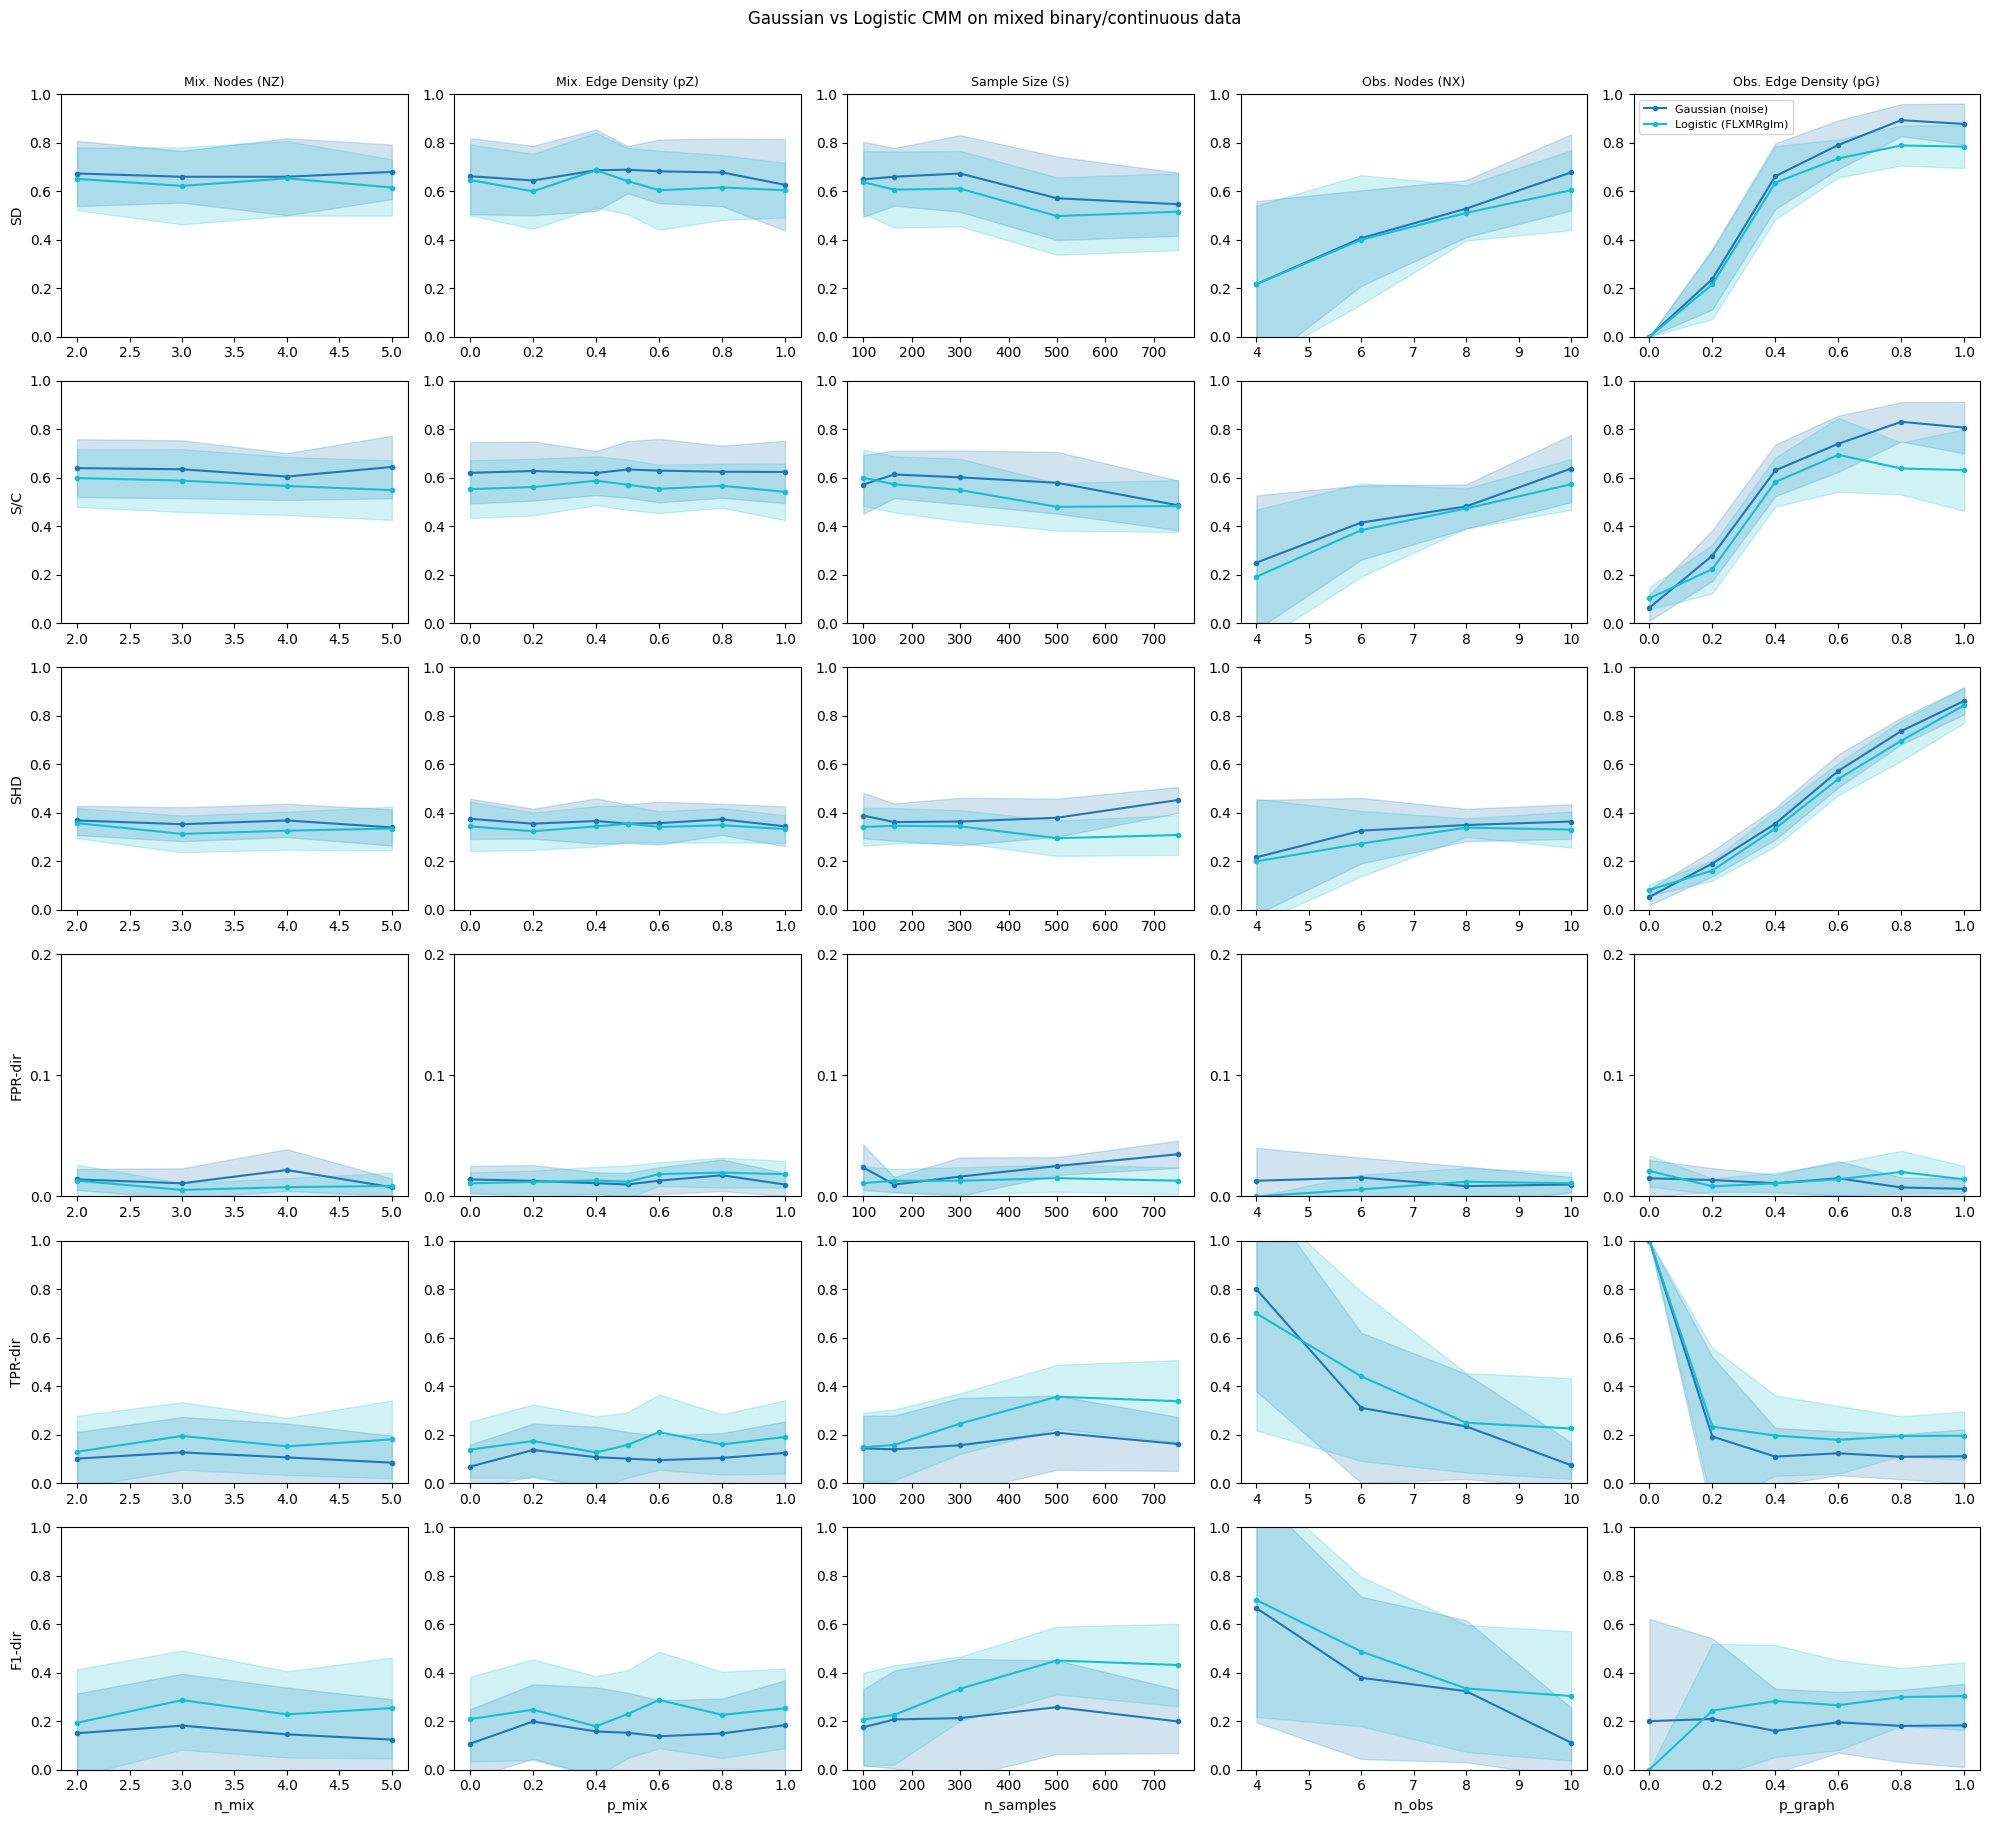

In [3]:
metric_labels = {
    'sd':  'SD',
    'sc':  'S/C',
    'shd': 'SHD',
    'fpr': 'FPR-dir',
    'tpr': 'TPR-dir',
    'f1':  'F1-dir',
}
plot_sweep(df, metrics=list(metric_labels), metric_labels=metric_labels,
           param_labels=PARAM_LABELS, group_col='model', group_labels=model_labels,
           title='Gaussian vs Logistic CMM on mixed binary/continuous data')

## Edge-type breakdown

Splits F1/precision/recall by edge class: mutation→mutation (`bin_bin`) vs mutation→MIC (`bin_cont`).

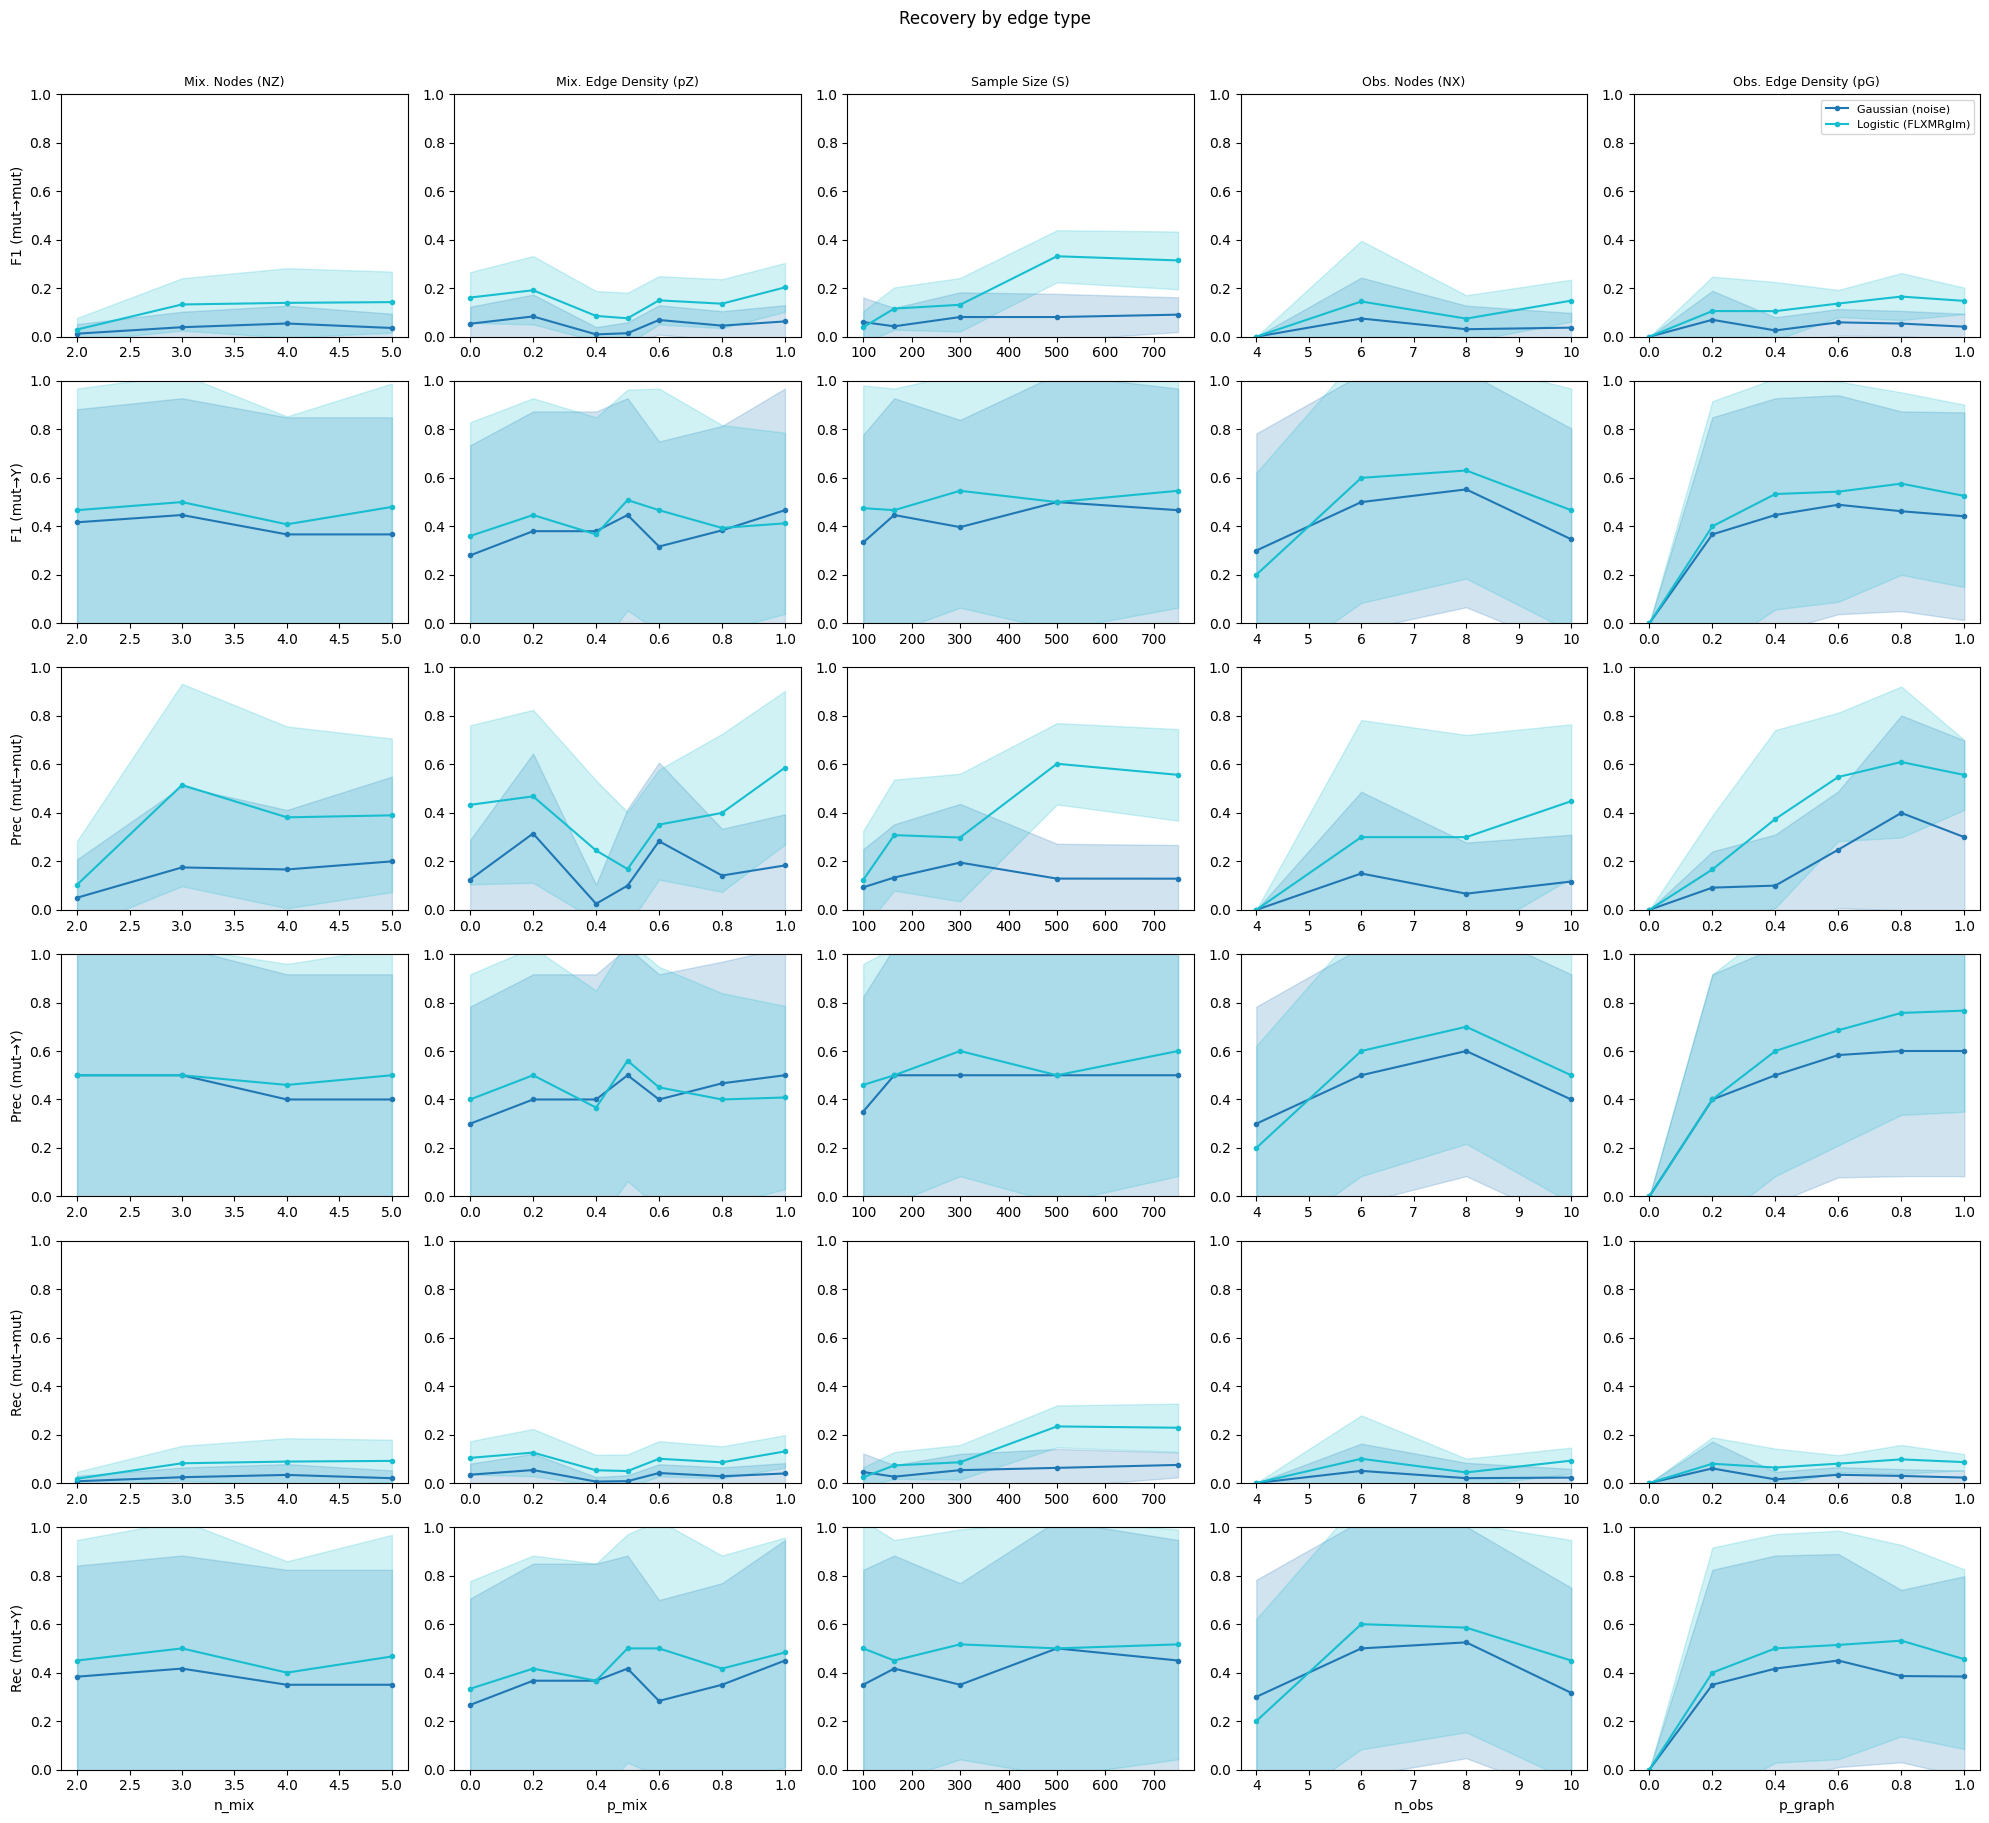

In [4]:
edge_metric_labels = {
    'f1_bin_bin':         'F1 (mut→mut)',
    'f1_bin_cont':        'F1 (mut→Y)',
    'precision_bin_bin':  'Prec (mut→mut)',
    'precision_bin_cont': 'Prec (mut→Y)',
    'recall_bin_bin':     'Rec (mut→mut)',
    'recall_bin_cont':    'Rec (mut→Y)',
}
plot_sweep(df, metrics=list(edge_metric_labels), metric_labels=edge_metric_labels,
           param_labels=PARAM_LABELS, group_col='model', group_labels=model_labels,
           title='Recovery by edge type')

## Defaults-only summary table

In [5]:
param_to_default = {k: DEFAULTS[k] for k in ('n_mix', 'p_mix', 'n_samples', 'n_obs', 'p_graph')}
mask = df.apply(lambda r: r['value'] == param_to_default.get(r['param']), axis=1)
df_def = df[mask]
summary = df_def.groupby('model')[['f1', 'tpr', 'fpr', 'shd', 'f1_bin_bin', 'f1_bin_cont']].mean().round(3)
summary.loc[models_order]

,f1,tpr,fpr,shd,f1_bin_bin,f1_bin_cont
model,,,,,,
gaussian,0.156,0.104,0.011,0.361,0.027,0.421
logistic,0.247,0.173,0.012,0.345,0.095,0.488
